# CFL quark-star deformation experiment

Edit the single settings cell and choose **Run All**. The first pass is a read-only preview with no scientific calculations or result writes. Review its case count, numerical stages, and destination. Change only `EXECUTE_REVIEWED_PLAN` to `True`, then **Run All** again in the same kernel to execute that exact plan once.

This notebook describes pure, cold, **bare self-bound CFL quark stars**, not hybrid stars or stars with a crust. It uses the approved full finite-strange-mass bag potential with the leading pairing term: $m_s=150$ MeV, $\Delta=100$ MeV, $B^{1/4}=165$ MeV, $a_4=1$. These values, the finite-density surface, constants, and the frozen baseline hash are owned by the package and cannot be swept here. See [the scientific contract](../docs/cfl.md).

Stellar mode computes full sampled **M–R, Λ–M, and k₂–M sequences**, refined maximum masses when resolvable, and requested comparison masses. `FIXED_MASSES=[1.4]` adds a gravitational-mass comparison point; it does **not** restrict the sequence to 1.4 M☉. Keep at least one positive requested mass; an unbracketed target is reported as unavailable. Quick and strict use the same physical acceptance rules.

In [42]:
from eos_generation.notebook import NotebookSettings, get_notebook_session

notebook_session = get_notebook_session()

## Experiment settings

`AMPLITUDES` is the dimensionless change in $c_s^2$ before the Gaussian and surface ramp are applied. `CENTER`, `WIDTH` (Gaussian σ), and `RAMP_WIDTH` use MeV fm$^{-3}$. The ramp starts at the fixed self-bound surface, ε ≈ 342.734 MeV fm$^{-3}$, and reaches one after `RAMP_WIDTH`. The declared upper endpoint is ε ≈ 4001.100 MeV fm$^{-3}$. There is no hadronic matching anchor or below-surface matter.

A scalar or list is accepted for each deformation control. Lists form a bounded Cartesian grid. The unchanged A=0 baseline is included automatically and shared between geometries. Start with the small **quick** example below. Change to **strict**, preview again, and explicitly execute for the governed convergence stages. Strict is more expensive; the preview shows all stages and target counts. Neither precision label guarantees physical validity or resolved observables.

In [43]:
# Edit only this cell. Scalars or lists define the deformation grid.
AMPLITUDES = [-0.20, -0.10, 0.00, 0.10, 0.20,0.30,0.40]
CENTER = 250.0
WIDTH = 500.0
RAMP_WIDTH = 10.0

CALCULATION = "stellar"       # "stellar" or "thermodynamics"
FIXED_MASSES = [1.4]           # gravitational M/M_sun; extra points, not the sequence grid
PRECISION = "quick"           # "quick" or "strict"

EXECUTE_REVIEWED_PLAN = True   # preview first; True executes the unchanged reviewed plan

# Optional: reopen an existing experiment WITHOUT scientific calculations.
# Paste the completed experiment folder printed by a previous run.
LOAD_EXPERIMENT = None         # e.g. r"../runs/cfl_.../experiment_..."
BUILD_SAVED_PLOTS = False      # True only to build a missing view for LOAD_EXPERIMENT

In [44]:
if not isinstance(EXECUTE_REVIEWED_PLAN, bool) or not isinstance(BUILD_SAVED_PLOTS, bool):
    raise TypeError("Execution and plotting controls must be exactly False or True.")
if LOAD_EXPERIMENT is not None and EXECUTE_REVIEWED_PLAN:
    raise ValueError("Choose load or execute, not both. Set EXECUTE_REVIEWED_PLAN=False to load.")
if BUILD_SAVED_PLOTS and LOAD_EXPERIMENT is None:
    raise ValueError("BUILD_SAVED_PLOTS is only for a saved LOAD_EXPERIMENT; new runs create their view automatically.")

settings = None
if LOAD_EXPERIMENT is None:
    settings = NotebookSettings.from_values(
        matter_model="cfl",
        epsilon_match="surface",
        amplitudes=AMPLITUDES,
        center=CENTER,
        width=WIDTH,
        ramp_width=RAMP_WIDTH,
        calculation=CALCULATION,
        fixed_masses=FIXED_MASSES,
        precision=PRECISION,
        diagnostics="off",  # extended CFL radial diagnostics are not established
    )

In [45]:
notebook_run = None
experiment_result = None
if LOAD_EXPERIMENT is None:
    notebook_run = notebook_session.prepare(
        settings, record_preview=not EXECUTE_REVIEWED_PLAN
    )
    print(notebook_run.summary_text())
else:
    experiment_result = notebook_session.load(LOAD_EXPERIMENT)
    if experiment_result.settings.matter_model != "cfl":
        raise ValueError("LOAD_EXPERIMENT must refer to a CFL experiment.")
    print("Loaded and validated saved CFL results; 0 scientific solver calls.")

Settings valid; exact experiment preview recorded.
Calculation: stellar
Requested cases: 7
Numerical precision: quick
Diagnostics: off
Automatic stellar worker limit: 6 (fewer for small batches; no nested pools).
Destination: C:\Users\johns\Downloads\EoS-generation-main\EoS-generation-main\runs\cfl_20260827T111301Z_1f181cd2774b\experiment_12316749bfc7
Preview cost: 0 solver calls, 0 filesystem writes.
Execution requires a second Run All with EXECUTE_REVIEWED_PLAN=True.
Quick changes numerical resolution only; physical acceptance gates are unchanged.

CFL experiment plan
Plan hash: b31104de7af3faff8a23740b0e4a23443e21bef558883d97ec762c2f2096f122
Calculation: stellar
Precision: quick
Geometries: 1
Cases: 7
Destination: C:\Users\johns\Downloads\EoS-generation-main\EoS-generation-main\runs\cfl_20260827T111301Z_1f181cd2774b\experiment_12316749bfc7
Planning is passive: yes (0 solver calls, 0 filesystem writes)
Baseline construction stage evaluations: 1
Deduplicated logical case aliases: 0
Di

In [46]:
if notebook_run is not None:
    experiment_result = notebook_session.execute(
        notebook_run,
        current_settings=settings,
        execute=EXECUTE_REVIEWED_PLAN,
    )
    if experiment_result is None:
        print("Preview only. Review the plan, then change EXECUTE_REVIEWED_PLAN to True and Run All again.")
    else:
        print(f"Completed experiment (copy this path to reopen): {experiment_result.experiment_path}")

Completed experiment (copy this path to reopen): C:\Users\johns\Downloads\EoS-generation-main\EoS-generation-main\runs\cfl_20260827T111301Z_1f181cd2774b\experiment_12316749bfc7


CFL experiment: COMPLETE
Path: C:\Users\johns\Downloads\EoS-generation-main\EoS-generation-main\runs\cfl_20260827T111301Z_1f181cd2774b\experiment_12316749bfc7
Calculation: stellar
Precision: quick
Geometries / child packets: 1
Accepted cases: 7
Rejected cases: 0
A=0 identity status: pass
Numerical convergence status: {'thermodynamic': 'insufficient_stages', 'stellar': 'single_stage_no_numerical_envelope'}
Stellar capability: requested
Figures: 13


### Saved CFL results

[Open combined plots and CSV tables](../runs/cfl_20260827T111301Z_1f181cd2774b/plots/) · 7 physical EoSs · 0 rejected proposals

`C000000` is the undeformed baseline. C labels are local to this experiment; canonical IDs remain in `case_catalogue.csv`. Lines are saved sampled sequences, not proof of stability. Dots mark successfully bracketed requested masses. Gaps and missing tides are retained.

**case_catalogue.csv**

,eos_label,geometry_index,amplitude,epsilon0_mev_fm3,sigma_mev_fm3,delta_mev_fm3,status,stellar_calculation,rejection_reason
0,C000000,1,0.0,250.0,500.0,10.0,accepted,completed,NaN
1,C000001,1,-0.2,250.0,500.0,10.0,accepted,completed,NaN
2,C000002,1,-0.1,250.0,500.0,10.0,accepted,completed,NaN
3,C000003,1,0.1,250.0,500.0,10.0,accepted,completed,NaN
4,C000004,1,0.2,250.0,500.0,10.0,accepted,completed,NaN
5,C000005,1,0.3,250.0,500.0,10.0,accepted,completed,NaN
6,C000006,1,0.4,250.0,500.0,10.0,accepted,completed,NaN


**fixed_mass_observables.csv**

,eos_label,stage,target_mass_msun,status,radius_km,k2,lambda_dimensionless,tidal_status
0,C000000,pilot_background,1.4,bracketed_and_solved,11.885079,0.200944,841.469956,validated_lambda_validation_v1
1,C000001,pilot_background,1.4,bracketed_and_solved,10.577156,0.115673,270.415752,validated_lambda_validation_v1
2,C000002,pilot_background,1.4,bracketed_and_solved,11.616841,0.181376,677.600217,validated_lambda_validation_v1
3,C000003,pilot_background,1.4,bracketed_and_solved,12.016692,0.210842,932.901382,validated_lambda_validation_v1
4,C000004,pilot_background,1.4,bracketed_and_solved,12.095984,0.216890,991.745080,validated_lambda_validation_v1
5,C000005,pilot_background,1.4,bracketed_and_solved,12.149253,0.220985,1032.914124,validated_lambda_validation_v1
6,C000006,pilot_background,1.4,bracketed_and_solved,12.187607,0.223945,1063.379309,validated_lambda_validation_v1


**maximum_mass_screening.csv**

,eos_label,stage,status,maximum_mass_resolved,maximum_mass_msun,radius_km,passes_maximum_mass_threshold,endpoint_limitation
0,C000000,pilot_background,resolved_unique_turning_point_local_sequence_r...,True,2.346694,12.433758,True,NaN
1,C000001,pilot_background,resolved_unique_turning_point_local_sequence_r...,True,1.533217,9.536145,False,NaN
2,C000002,pilot_background,resolved_unique_turning_point_local_sequence_r...,True,1.968067,11.408057,True,NaN
3,C000003,pilot_background,resolved_unique_turning_point_local_sequence_r...,True,2.652749,13.138713,True,NaN
4,C000004,pilot_background,resolved_unique_turning_point_local_sequence_r...,True,2.902387,13.674472,True,NaN
5,C000005,pilot_background,resolved_unique_turning_point_local_sequence_r...,True,3.109681,14.103659,True,NaN
6,C000006,pilot_background,resolved_unique_turning_point_local_sequence_r...,True,3.284838,14.459249,True,NaN


,figure,status,reason,physical_curve_count,plotted_sequence_or_profile_rows,omitted_sequence_or_profile_rows,partial
0,mass_radius.png,generated,saved final-stage rows only; gaps retained,7,119,0,False
1,lambda_mass.png,generated,saved final-stage rows only; gaps retained,7,119,0,False
2,k2_mass.png,generated,saved final-stage rows only; gaps retained,7,119,0,False
3,sound_speed.png,generated,saved final-stage rows only; gaps retained,7,5395,0,False
4,pressure.png,generated,saved final-stage rows only; gaps retained,7,5395,0,False
5,baryon_density.png,generated,saved final-stage rows only; gaps retained,7,5395,0,False
6,chemical_potential.png,generated,saved final-stage rows only; gaps retained,7,5395,0,False


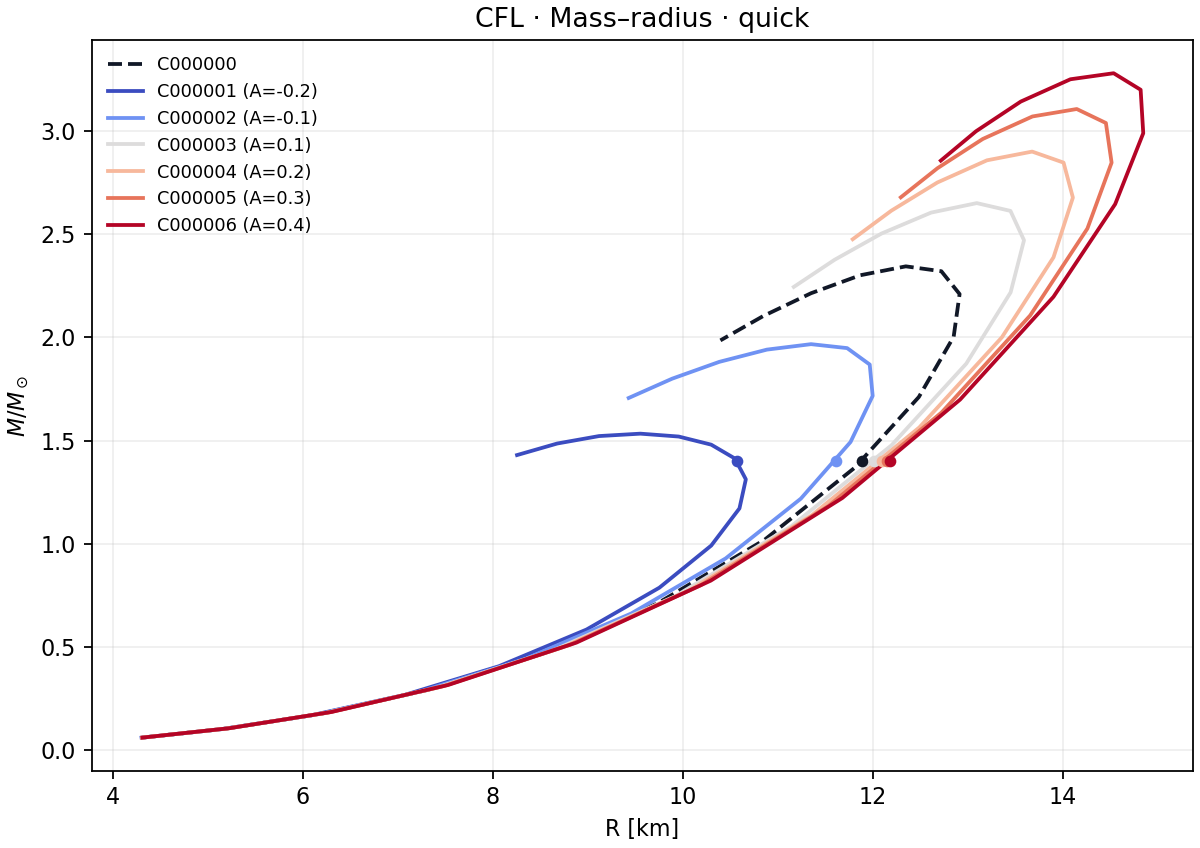

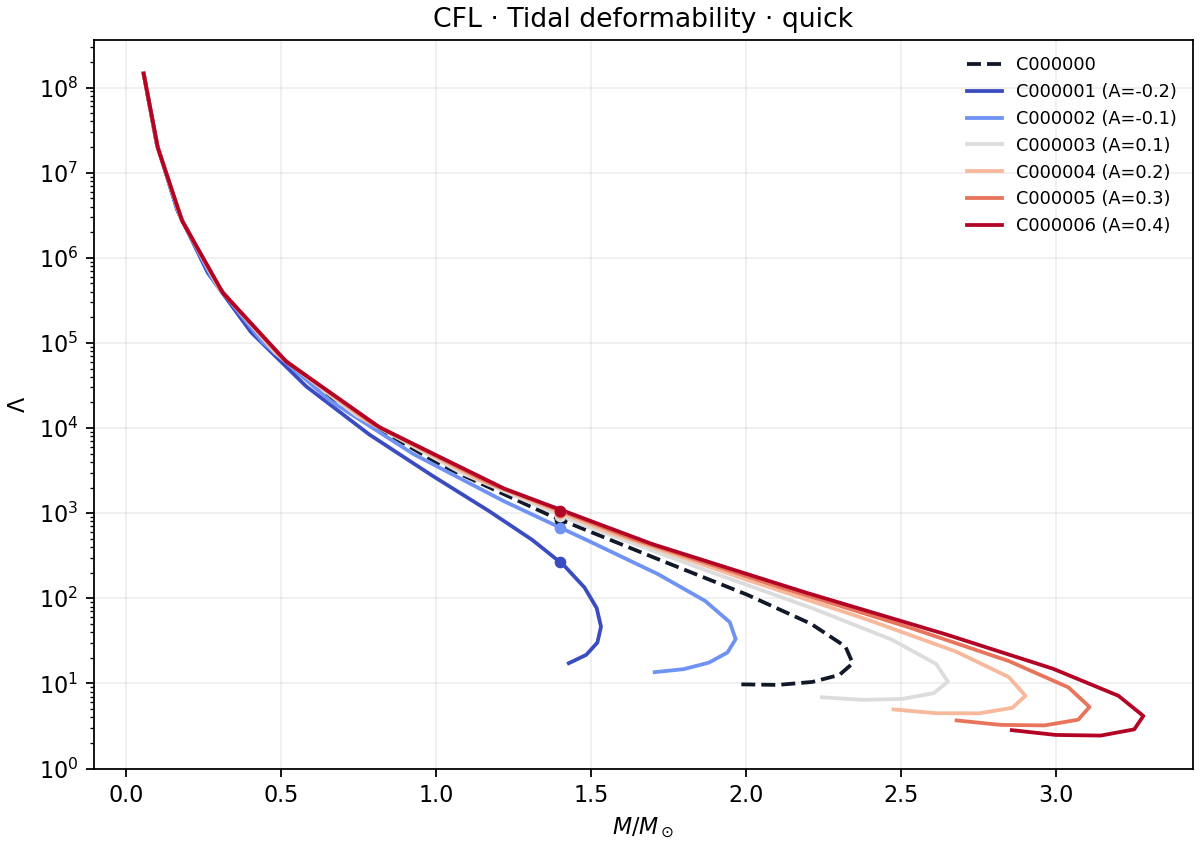

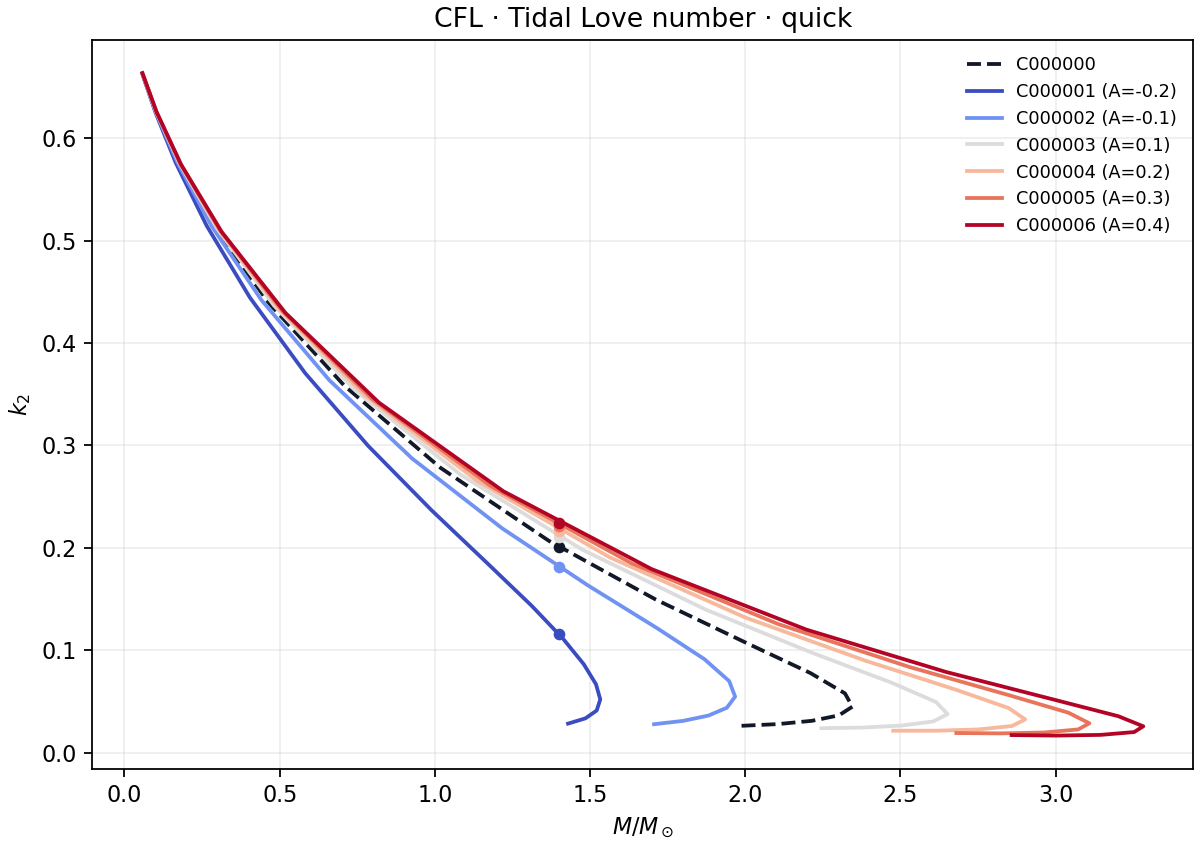

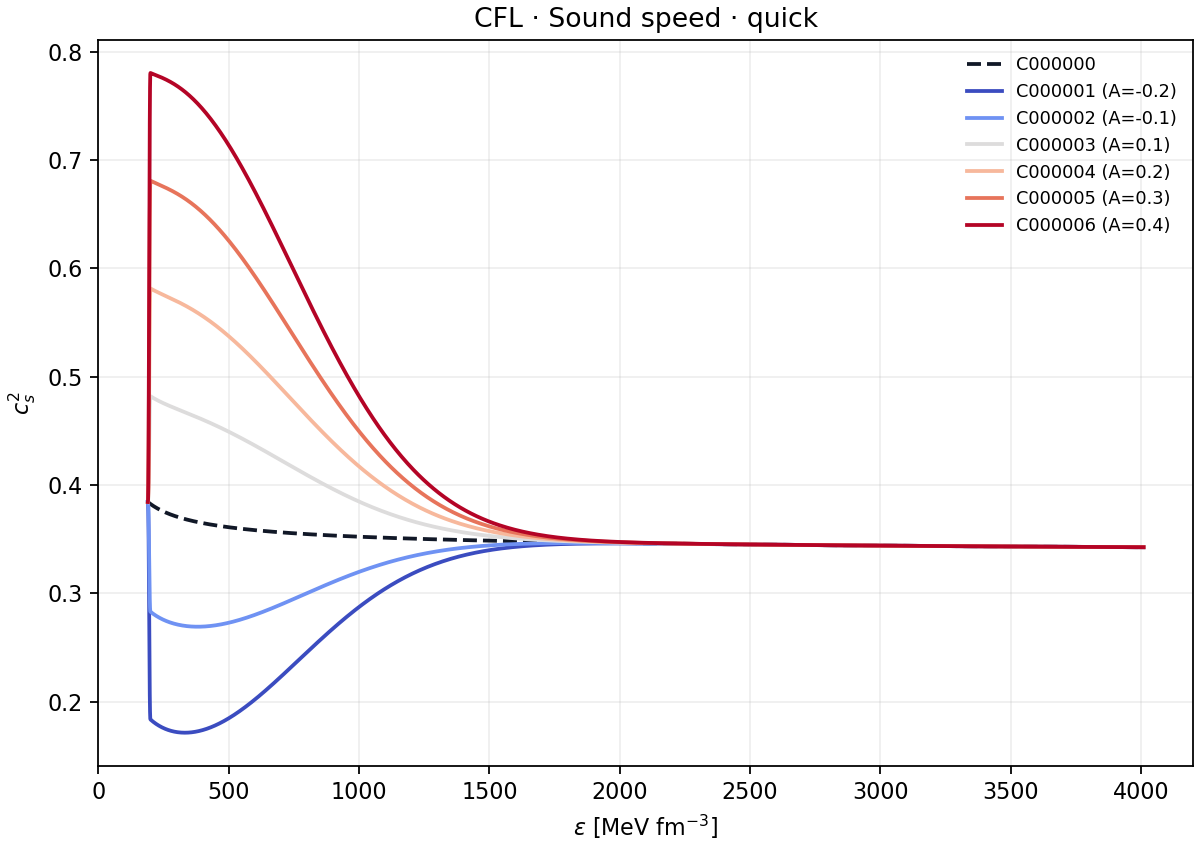

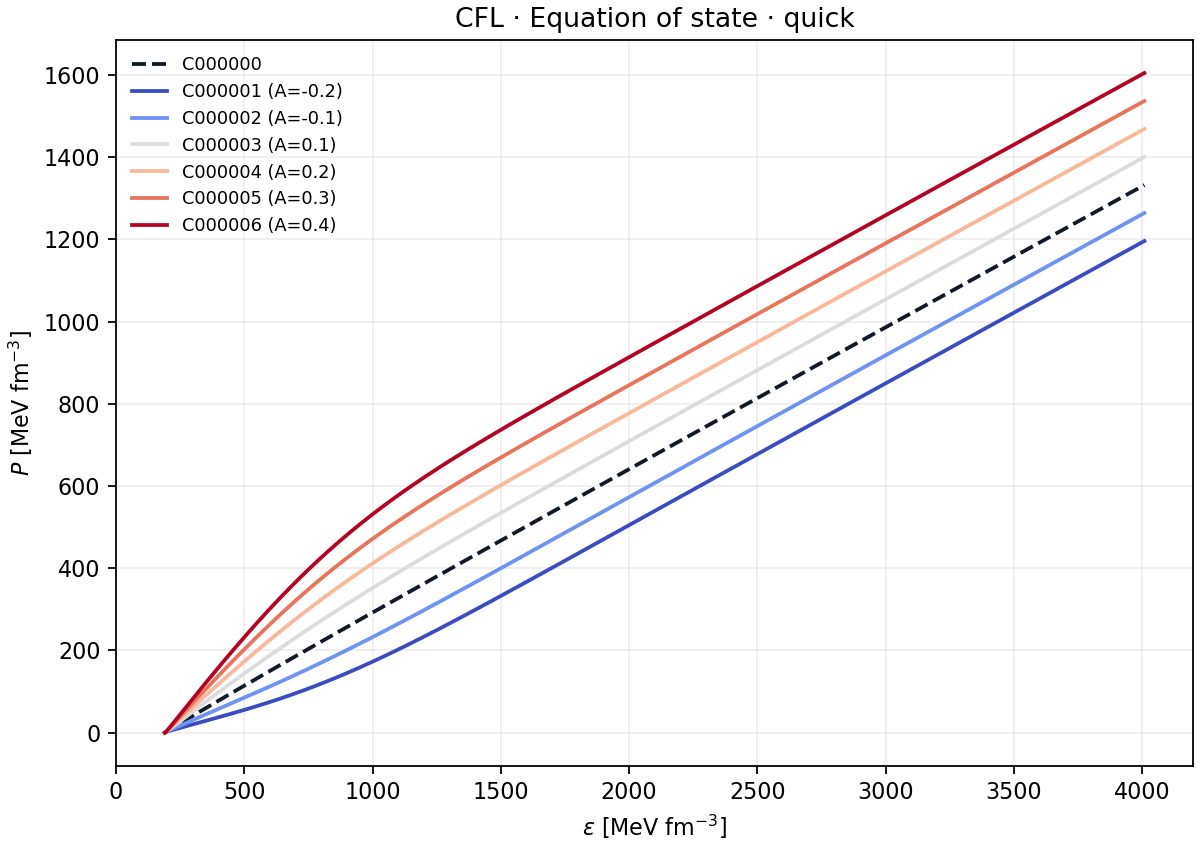

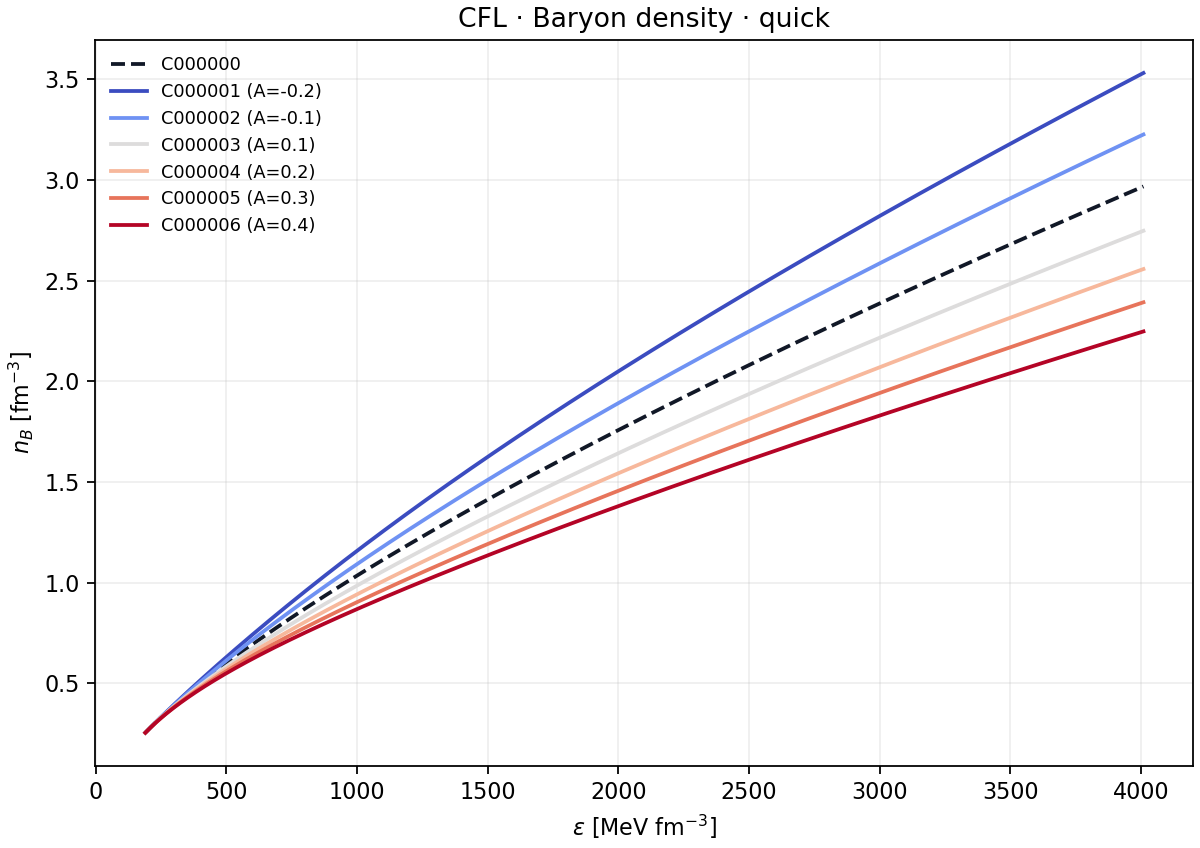

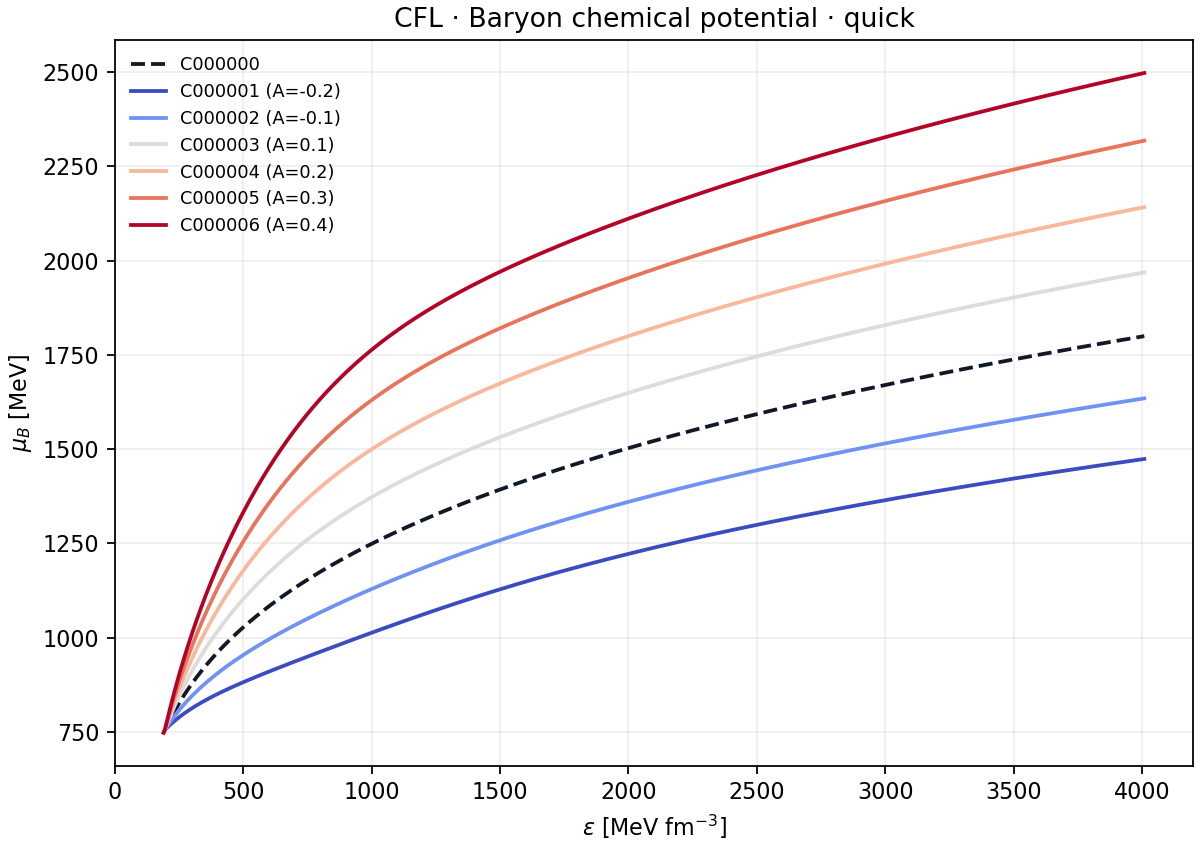

In [47]:
if experiment_result is not None:
    try:
        saved_view = notebook_session.present(
            experiment_result,
            create=EXECUTE_REVIEWED_PLAN or BUILD_SAVED_PLOTS,
        )
    except Exception:
        print("Saved scientific results are retained. If only presentation failed, reopen with LOAD_EXPERIMENT and BUILD_SAVED_PLOTS=True; do not rerun solvers to recover plots.")
        raise

## Reading your results

The combined view is a separate flat `plots/` folder beside the sealed experiment and `STUDENT_VIEW/`. It overlays accepted physical EoSs from every geometry, shows A=0 once, and contains M–R, Λ–M, k₂–M plus thermodynamic PNGs, combined thermodynamic/stellar CSV tables, a case catalogue, fixed-mass/maximum-mass tables, an availability inventory, and a hash manifest. `C000000` is the baseline and later six-digit C labels are convenient **local** labels, not persistent identifiers; canonical physical IDs and exact rejection reasons remain in the tables. Archive the entire timestamped run folder.

Rejected raw proposals receive no reconstruction or stellar calculations. A missing tidal curve is reported as unavailable, never invented. Curves use the final requested numerical stage; every stage, failure, surface-jump diagnostic, and A=0 identity check remains in the authoritative packets. No plot smooths or interpolates missing data, and failed sequence gaps are not bridged. The full sampled sequence may extend beyond the stable branch: curves alone are not a stability claim. A sampled peak is not a refined maximum mass. Maximum-mass availability and the configured mass-threshold comparison flag are separate from EoS validity and fixed-mass availability.

The finite self-bound surface tidal correction is applied exactly once by the solver, before k₂ and Λ are reported. Plotting does not apply it again. The deformed EoS is an effective cold one-fluid barotrope, not a microscopic proof of CFL composition throughout. Ordinary-nuclei/two-flavor stability is the explicitly retained external assumption in the frozen scientific contract.

To reopen results, set `EXECUTE_REVIEWED_PLAN=False`, paste the completed experiment path into `LOAD_EXPERIMENT`, and Run All. This is read-only by default. `BUILD_SAVED_PLOTS=True` explicitly creates a missing combined view from saved tables only; it never overwrites a view or reruns physics. For another scientific run, clear `LOAD_EXPERIMENT`, set `BUILD_SAVED_PLOTS=False`, and preview with execution disabled.